
# Variance analysis across rankers (TREC-COVID)

Sweep expected samples `m` (via `WeirdSamplingMatrixOracle`) across multiple seeds for every ranker except BM25, then visualize metric variance with boxplots.


In [22]:

import pandas as pd
import matplotlib.pyplot as plt

from ireranker.rankers import get_ranker, list_rankers
from ireranker.oracles import WeirdSamplingMatrixOracle
from ireranker.evaluation.beir import evaluate_rankers_beir
from ireranker.data.loaders import load_beir_dataset

# Configuration
DATASET = "trec-covid"
SPLIT = "test"
M_VALUES = [1.0, 1.25, 1.5, 1.75, 2.0]
SEEDS = list(range(30))
K_VALUES = [10]
MATRIX_MODEL = None  # set to a string to target a specific rerank matrix model


In [23]:

# Load dataset once; assumes rerank matrices for TREC-COVID are already present locally.
dataset = load_beir_dataset(DATASET, split=SPLIT, matrix_model=MATRIX_MODEL)
task_qids = [t.query_id for t in dataset.tasks]
print(f"Loaded {DATASET} with {len(dataset.tasks)} queries")


2025-12-02 17:58:02.555 | INFO     | ireranker.data.loaders:_download_beir_once:85 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/trec-covid
2025-12-02 17:58:02.788 | INFO     | ireranker.data.loaders:_load_rerank_matrix:170 - Loaded rerank matrix for trec-covid/test (queries: 50)
2025-12-02 17:58:02.788 | INFO     | ireranker.data.loaders:load_beir_dataset:262 - Using rerank matrix for 50 queries in trec-covid/test
2025-12-02 17:58:02.817 | INFO     | ireranker.data.loaders:load_beir_dataset:272 - Query coverage for trec-covid/test -> matrix: 50, qrels: 50, shared: 50, matrix-only: 0, qrels-only: 0
Loaded trec-covid with 50 queries


In [24]:
ranker_names = [r for r in list_rankers() if r.lower() != "bm25"]
print(f"Rankers to evaluate ({len(ranker_names)}): {', '.join(ranker_names)}")

import os
os.environ["TQDM_DISABLE"] = "1"  # suppress tqdm bars to keep logs compact


def _build_rankers(m: float, seed: int):
    """Build rankers using a WeirdSamplingMatrixOracle parameterized by m."""
    rankers = []
    for name in ranker_names:
        oracle = WeirdSamplingMatrixOracle(seed=seed, expected_samples=m)
        r = get_ranker(name, oracle=oracle, seed=seed)
        r.display_name = f"{name} [weird m={m}]"
        r.oracle_label = f"weird m={m}"
        r.set_dataset(DATASET, split=SPLIT, query_ids=task_qids, matrix_model=MATRIX_MODEL)
        rankers.append(r)
    return rankers

def run_variance_sweep():
    from IPython.display import display, clear_output
    
    rows = []
    total = len(M_VALUES) * len(SEEDS)
    step = 0
    for m in M_VALUES:
        for seed in SEEDS:
            step += 1
            status = f"[{step:>3}/{total}] m={m} seed={seed}"
            clear_output(wait=True)
            print(status)
            rankers = _build_rankers(m, seed)
            results = evaluate_rankers_beir(rankers, dataset, K_VALUES, seed=seed)
            for row in results:
                if int(row.get("k", 0)) not in K_VALUES:
                    continue
                rows.append(
                    {
                        "ranker": row["ranker"],
                        "oracle": row.get("oracle"),
                        "m": m,
                        "seed": seed,
                        "k": int(row["k"]),
                        "NDCG@10": float(row["NDCG"]),
                        "MAP@10": float(row["MAP"]),
                        "Recall@10": float(row["Recall"]),
                        "P@10": float(row["Precision"]),
                        "comparisons": int(row["Comparisons"]),
                        "cache_hits": int(row.get("CacheHits", 0)),
                    }
                )
    clear_output(wait=True)
    print(f"✓ Completed {total} sweeps. Collected {len(rows)} rows.")
    return pd.DataFrame(rows)

# Set to True to actually run the sweep (can take time).
RUN_SWEEP = True
df = run_variance_sweep() if RUN_SWEEP else pd.DataFrame()
df.head()

✓ Completed 150 sweeps. Collected 750 rows.


,ranker,oracle,m,seed,k,NDCG@10,MAP@10,Recall@10,P@10,comparisons,cache_hits
0,bubble sort (classic),weird m=1.0,1.0,0,10,0.76748,0.01908,0.02080,0.824,205061,0
1,mohajer (ir),weird m=1.0,1.0,0,10,0.77475,0.01935,0.02110,0.830,11626,0
2,prp sort (classic),weird m=1.0,1.0,0,10,0.75199,0.01929,0.02118,0.822,46036,0
3,quick sort (classic),weird m=1.0,1.0,0,10,0.76344,0.01909,0.02089,0.826,29551,0
4,sliding window prp (classic),weird m=1.0,1.0,0,10,0.78237,0.01963,0.02100,0.834,49500,0


In [25]:

if df.empty:
    print("No data yet; set RUN_SWEEP = True in the previous cell and re-run.")
else:
    summary = (
        df.groupby(["ranker", "m"])["NDCG@10"].agg(["mean", "std", "count"]).reset_index()
    )
    display(summary)


,ranker,m,mean,std,count
0,bubble sort (classic),1.00,0.777173,0.005526,30
1,bubble sort (classic),1.25,0.775389,0.007190,30
2,bubble sort (classic),1.50,0.771166,0.005298,30
3,bubble sort (classic),1.75,0.762221,0.004546,30
4,bubble sort (classic),2.00,0.748180,0.000000,30
5,mohajer (ir),1.00,0.764917,0.008919,30
6,mohajer (ir),1.25,0.767364,0.010491,30
7,mohajer (ir),1.50,0.769494,0.007252,30
8,mohajer (ir),1.75,0.769759,0.006792,30
9,mohajer (ir),2.00,0.769630,0.000000,30


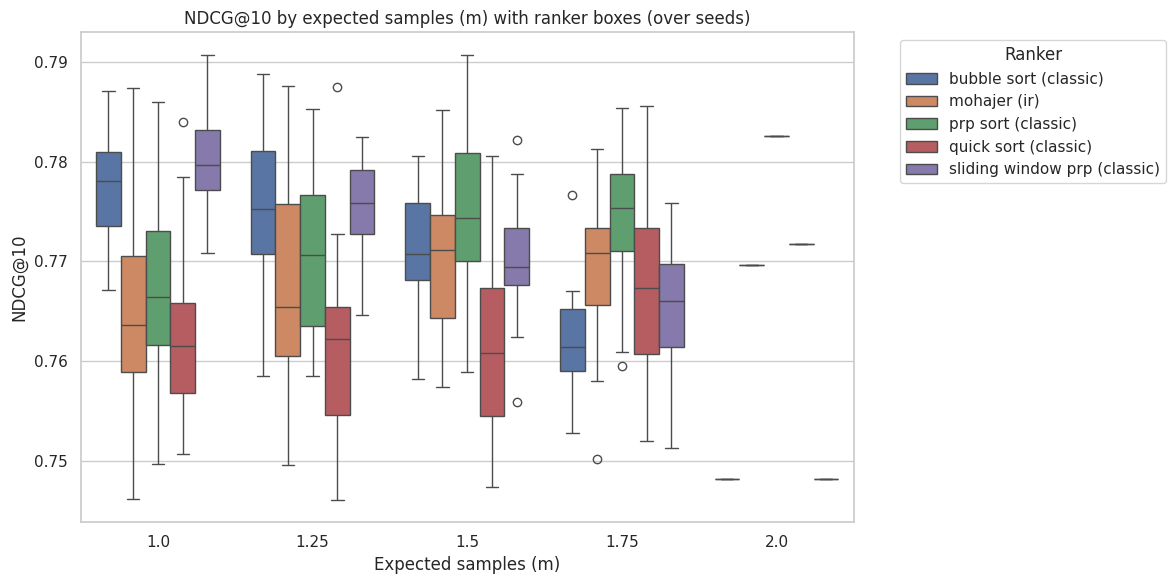

In [26]:
# Combined boxplot: x=m, boxes per ranker (distribution over seeds)
if df.empty:
    print("No data yet; set RUN_SWEEP = True earlier.")
else:
    try:
        import seaborn as sns

        sns.set_theme(style="whitegrid")
        plt.figure(figsize=(12, 6))
        ax = sns.boxplot(
            data=df,
            x="m",
            y="NDCG@10",
            hue="ranker",
            order=sorted(df["m"].unique()),
        )
        ax.set_title("NDCG@10 by expected samples (m) with ranker boxes (over seeds)")
        ax.set_xlabel("Expected samples (m)")
        ax.set_ylabel("NDCG@10")
        plt.legend(title="Ranker", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("Install seaborn to plot NDCG@10 by m and ranker.")
